In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/dataset.csv")
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [2]:
# Dimensiones: cuántas filas y columnas
print("Shape:", df.shape)

# Listado de todas las columnas y su tipo
print("\nColumnas y tipos:")
print(df.dtypes)

# Valores nulos por columna
print("\nNulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas de las numéricas
df.describe()

Shape: (114000, 21)

Columnas y tipos:
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

Nulos por columna:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumen

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [3]:
# 1. Borramos la columna basura
df = df.drop(columns=["Unnamed: 0"])

# 2. Confirmamos nulos en TODAS las columnas (la salida anterior estaba truncada)
print("Total de nulos en el dataset:", df.isnull().sum().sum())

# 3. ¿Cuántos géneros hay y cuántas canciones por género?
print("\nNúmero de géneros únicos:", df["track_genre"].nunique())
print("\nTop 10 géneros por número de canciones:")
print(df["track_genre"].value_counts().head(10))

# 4. ¿Cuántas canciones "corruptas" tenemos (duración=0 o tempo=0)?
corruptas = df[(df["duration_ms"] == 0) | (df["tempo"] == 0)]
print(f"\nCanciones con duración o tempo = 0: {len(corruptas)}")

# 5. ¿Cuántas tienen popularity = 0?
print(f"Canciones con popularity = 0: {(df['popularity'] == 0).sum()}")

Total de nulos en el dataset: 3

Número de géneros únicos: 114

Top 10 géneros por número de canciones:
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

Canciones con duración o tempo = 0: 158
Canciones con popularity = 0: 16020


In [4]:
# Estado inicial
print("Filas antes de limpiar:", len(df))

# 1. Eliminar los 3 nulos
df = df.dropna()

# 2. Eliminar canciones con duración o tempo = 0
df = df[(df["duration_ms"] > 0) & (df["tempo"] > 0)]

# 3. Filtrar popularity = 0 (datos probablemente faltantes)
df = df[df["popularity"] > 0]

# 4. Crear columna duration_min para tener duración en minutos (más legible)
df["duration_min"] = df["duration_ms"] / 60000

print("Filas después de limpiar:", len(df))
print(f"Canciones eliminadas: {114000 - len(df)}")

Filas antes de limpiar: 114000
Filas después de limpiar: 97827
Canciones eliminadas: 16173


TOP 20 GÉNEROS MÁS POPULARES
track_genre
pop-film             59.401804
k-pop                59.204995
pop                  58.161369
electro              57.905297
house                57.212730
chill                55.886458
metal                54.974843
edm                  54.909091
indie-pop            54.867746
indie                54.474790
sad                  53.122718
hip-hop              53.106892
alt-rock             52.139785
progressive-house    51.967670
grunge               51.553015
soul                 50.886889
emo                  50.554622
piano                50.191796
songwriter           50.149867
singer-songwriter    50.149867
Name: popularity, dtype: float64

BOTTOM 20 GÉNEROS MENOS POPULARES
track_genre
study             26.451874
heavy-metal       26.278557
bluegrass         25.935354
afrobeat          24.770558
j-idol            24.756513
comedy            24.628000
happy             22.691745
black-metal       22.516550
classical         21.686047
breakbe

C:\Users\alexg\AppData\Local\Temp\ipykernel_8112\3274666654.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette="viridis")


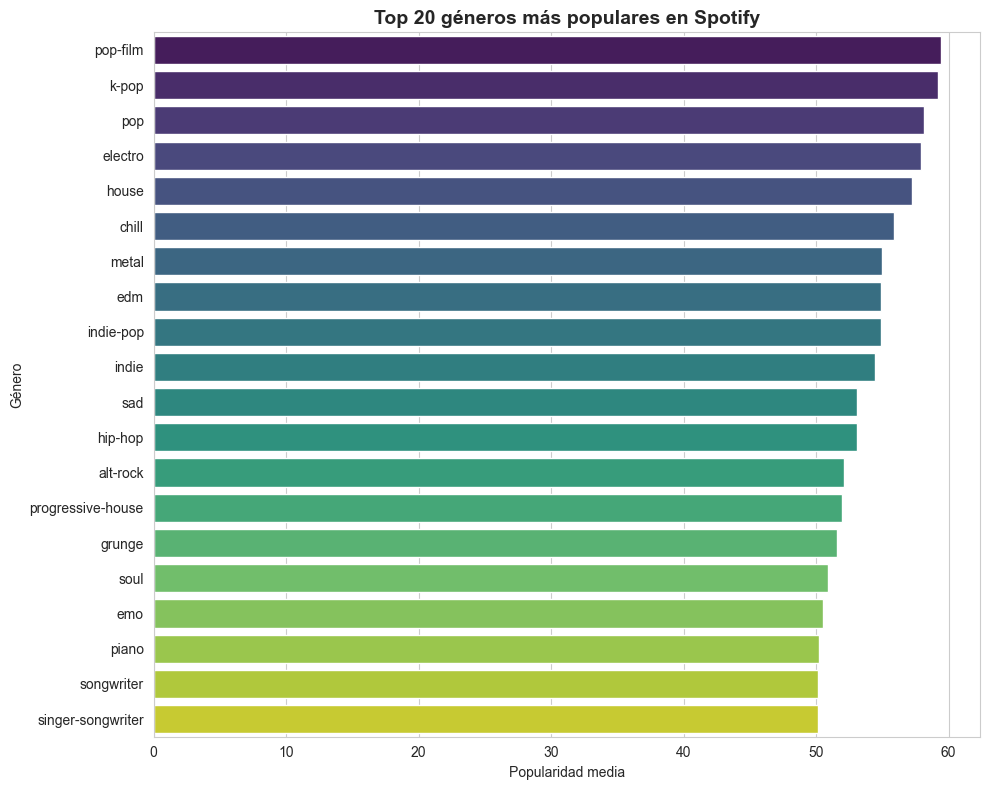

In [ ]:
# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)

# 1. Popularidad media por género
pop_por_genero = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)

# 2. Top 20 géneros más populares
top20 = pop_por_genero.head(20)
print("TOP 20 GÉNEROS MÁS POPULARES")
print(top20)

# 3. Bottom 20 géneros menos populares
bottom20 = pop_por_genero.tail(20)
print("\nBOTTOM 20 GÉNEROS MENOS POPULARES")
print(bottom20)

# 4. Gráfico del Top 20
plt.figure(figsize=(10, 8))
sns.barplot(x=top20.values, y=top20.index, palette="viridis")
plt.title("Top 20 géneros más populares en Spotify", fontsize=14, fontweight="bold")
plt.xlabel("Popularidad media")
plt.ylabel("Género")
plt.tight_layout()
plt.savefig("top20_generos.png", dpi=150, bbox_inches="tight")
plt.show()

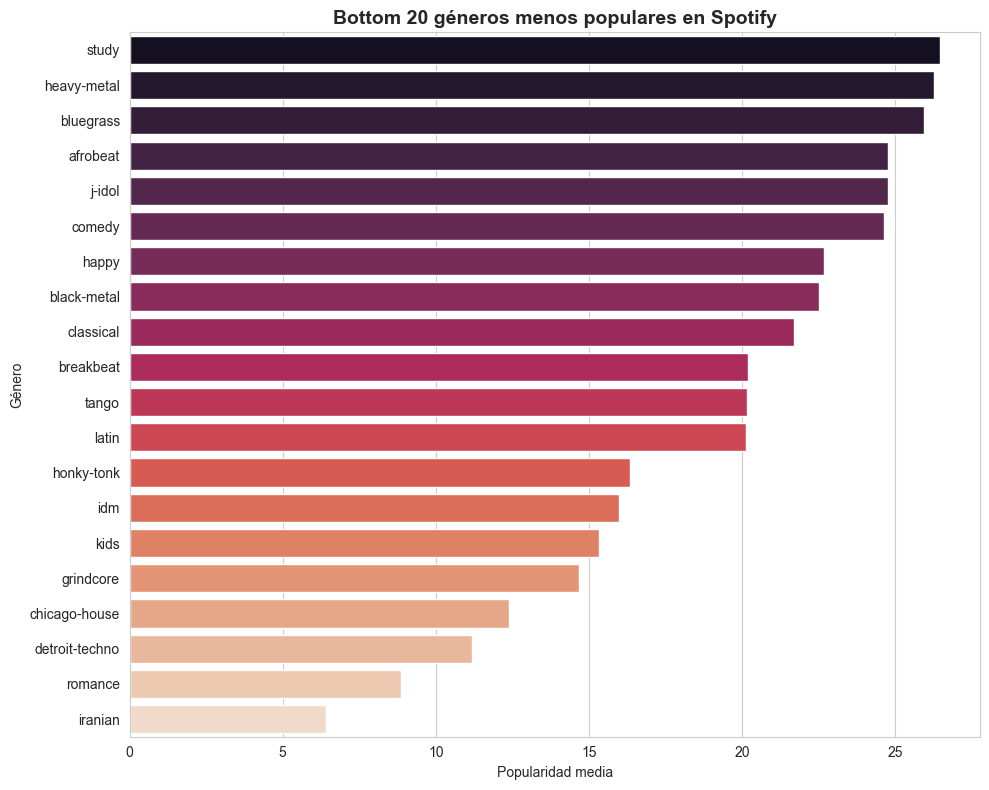

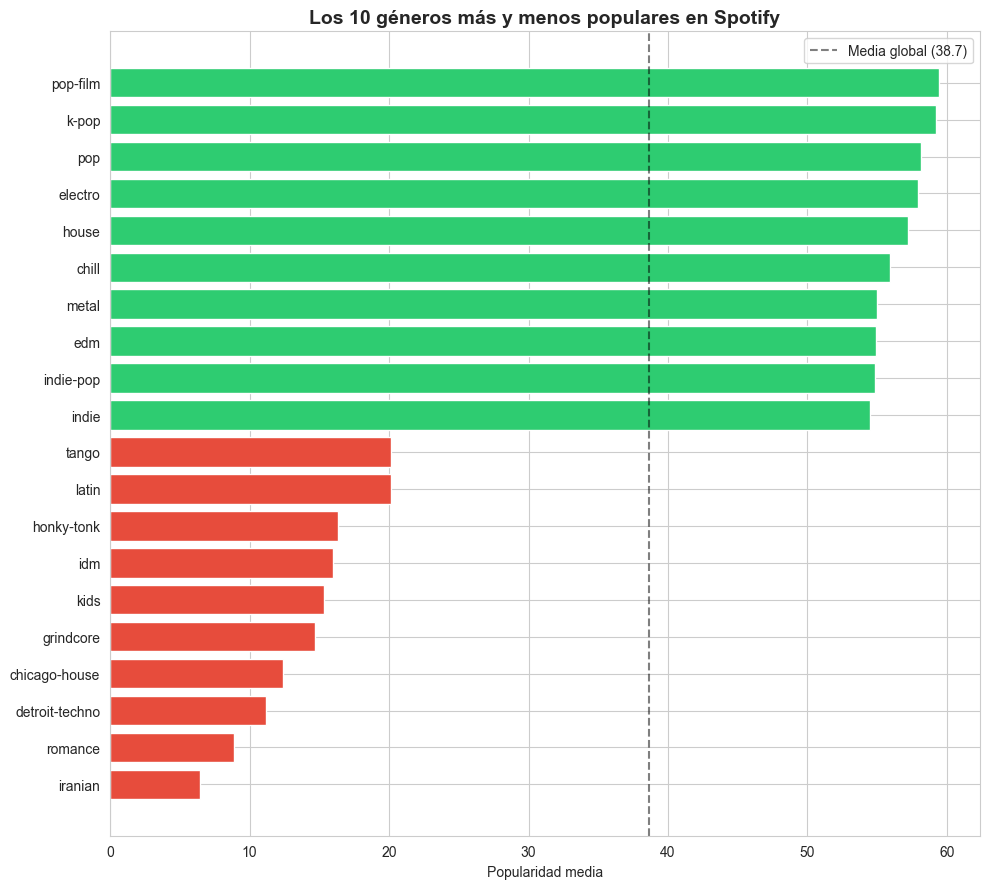

Popularidad media global: 38.67
Diferencia entre el género #1 y el último: 53.0 puntos
Desviación estándar entre géneros: 12.14


In [6]:
# Bottom 20 con paleta arreglada (asignando hue explícitamente)
plt.figure(figsize=(10, 8))
sns.barplot(x=bottom20.values, y=bottom20.index, hue=bottom20.index, palette="rocket", legend=False)
plt.title("Bottom 20 géneros menos populares en Spotify", fontsize=14, fontweight="bold")
plt.xlabel("Popularidad media")
plt.ylabel("Género")
plt.tight_layout()
plt.savefig("bottom20_generos.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfico combinado: top 10 vs bottom 10 (el más vistoso para el README)
top10 = pop_por_genero.head(10)
bot10 = pop_por_genero.tail(10)
combinado = pd.concat([top10, bot10])
colores = ["#2ecc71"] * 10 + ["#e74c3c"] * 10  # verde arriba, rojo abajo

plt.figure(figsize=(10, 9))
plt.barh(combinado.index[::-1], combinado.values[::-1], color=colores[::-1])
plt.title("Los 10 géneros más y menos populares en Spotify", fontsize=14, fontweight="bold")
plt.xlabel("Popularidad media")
plt.axvline(x=df["popularity"].mean(), color="black", linestyle="--", alpha=0.5, label=f"Media global ({df['popularity'].mean():.1f})")
plt.legend()
plt.tight_layout()
plt.savefig("top_vs_bottom_generos.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticas clave para el README
print(f"Popularidad media global: {df['popularity'].mean():.2f}")
print(f"Diferencia entre el género #1 y el último: {top10.iloc[0] - bot10.iloc[-1]:.1f} puntos")
print(f"Desviación estándar entre géneros: {pop_por_genero.std():.2f}")

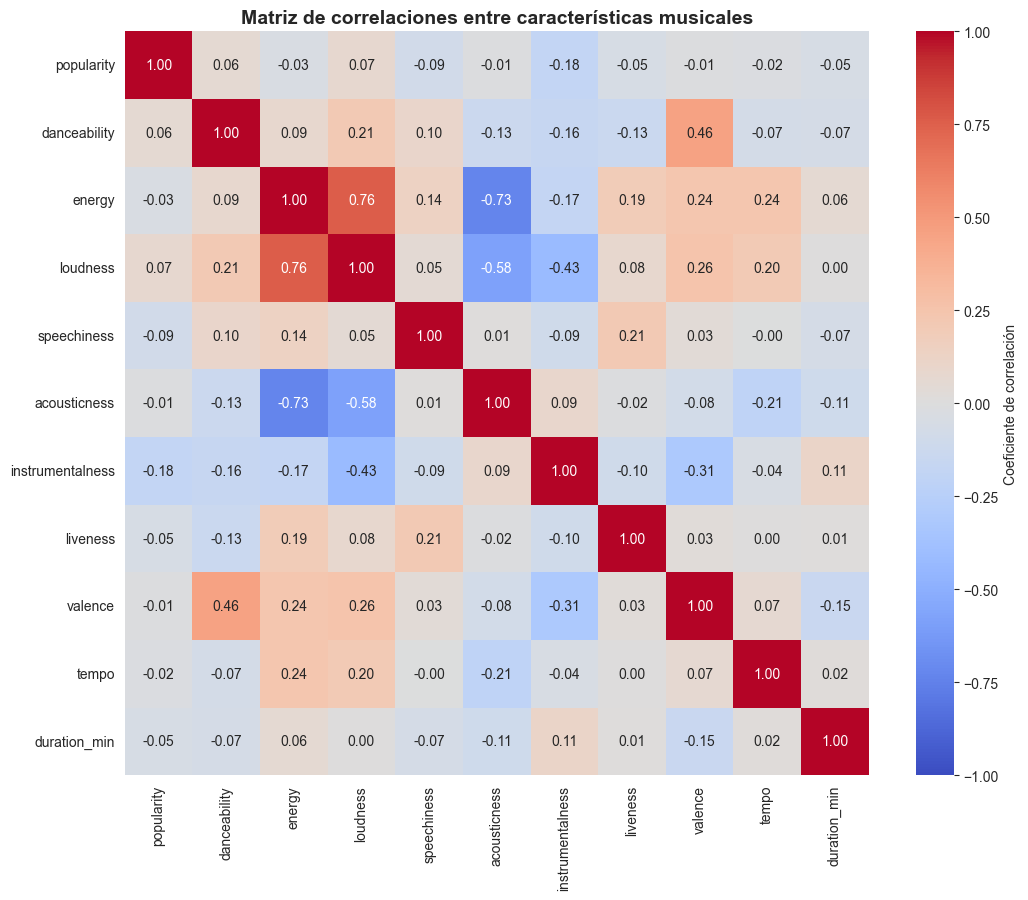


Correlación de cada feature con popularity (ordenada):
instrumentalness   -0.182121
speechiness        -0.090394
duration_min       -0.052668
liveness           -0.052061
energy             -0.033710
tempo              -0.018531
valence            -0.013308
acousticness       -0.009147
danceability        0.061745
loudness            0.072120
Name: popularity, dtype: float64


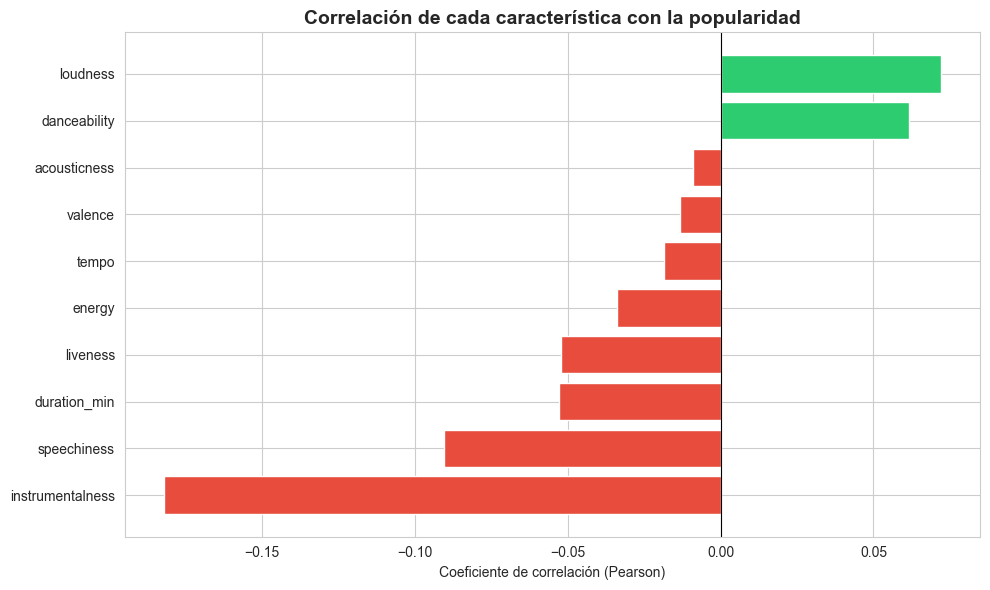

In [7]:
# Seleccionamos solo las variables numéricas que nos interesan
audio_features = [
    "popularity", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_min"
]

# 1. Matriz de correlación completa
corr_matrix = df[audio_features].corr()

# 2. Heatmap de correlaciones
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Coeficiente de correlación"})
plt.title("Matriz de correlaciones entre características musicales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Correlación específica con popularity (ordenada)
corr_pop = corr_matrix["popularity"].drop("popularity").sort_values()
print("\nCorrelación de cada feature con popularity (ordenada):")
print(corr_pop)

# 4. Gráfico de barras: cada feature vs popularity
plt.figure(figsize=(10, 6))
colores = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_pop.values]
plt.barh(corr_pop.index, corr_pop.values, color=colores)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Correlación de cada característica con la popularidad", fontsize=14, fontweight="bold")
plt.xlabel("Coeficiente de correlación (Pearson)")
plt.tight_layout()
plt.savefig("correlaciones_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

Popularidad por rango de tempo:
                mean  count
tempo_bin                  
<60        34.532423    293
60-80      38.474694   6046
80-100     39.307983  18540
100-120    39.132707  20112
120-140    38.266200  26882
140-160    39.393364  13471
160-180    37.299550   9551
>180       37.251705   2932

Popularidad por rango de duración (minutos):
                   mean  count
duration_bin                  
<2            31.423823   5566
2-2.5         38.049557   7446
2.5-3         40.013478  13874
3-3.5         40.952578  18367
3.5-4         41.166274  17423
4-4.5         39.435122  12300
4.5-5         38.411544   8004
5-6           36.394118   7820
>6            31.801338   7027


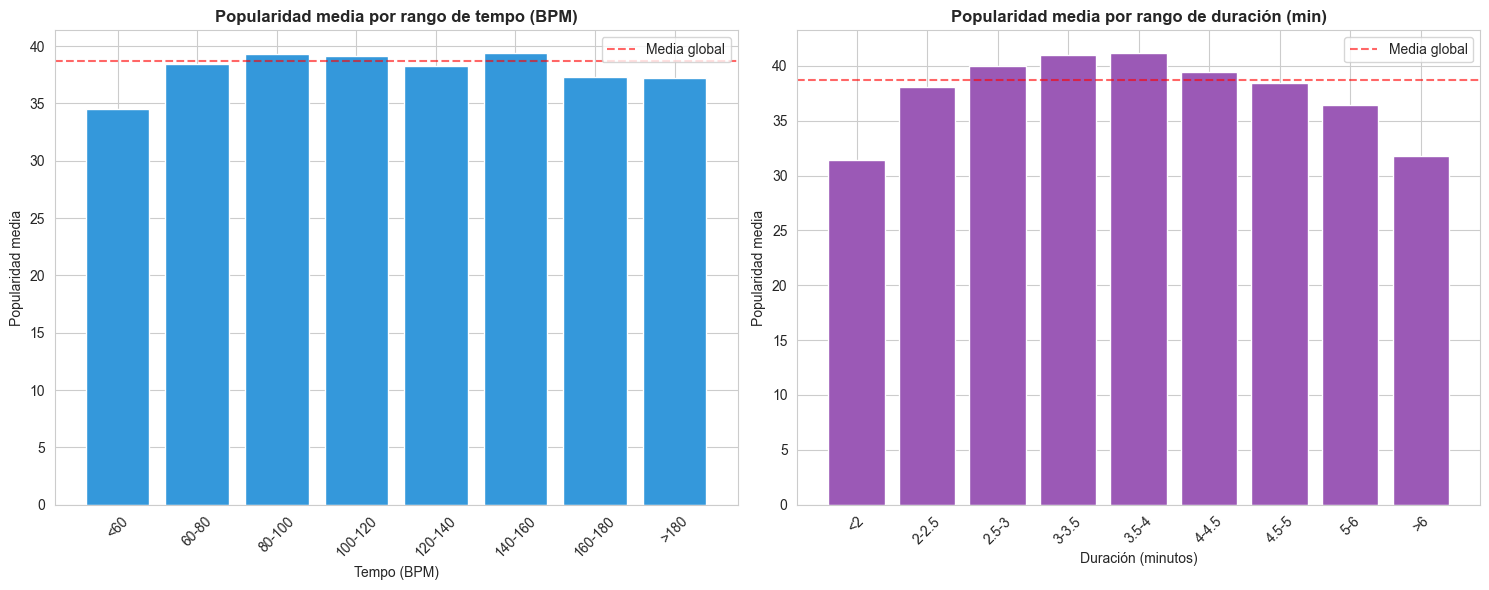

In [8]:
# 1. Crear bins de tempo (rangos de 20 BPM)
bins_tempo = [0, 60, 80, 100, 120, 140, 160, 180, 250]
labels_tempo = ["<60", "60-80", "80-100", "100-120", "120-140", "140-160", "160-180", ">180"]
df["tempo_bin"] = pd.cut(df["tempo"], bins=bins_tempo, labels=labels_tempo)

# 2. Popularity media por bin de tempo
pop_por_tempo = df.groupby("tempo_bin", observed=True)["popularity"].agg(["mean", "count"])
print("Popularidad por rango de tempo:")
print(pop_por_tempo)

# 3. Crear bins de duración (en minutos)
bins_dur = [0, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 100]
labels_dur = ["<2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5", "5-6", ">6"]
df["duration_bin"] = pd.cut(df["duration_min"], bins=bins_dur, labels=labels_dur)

pop_por_duracion = df.groupby("duration_bin", observed=True)["popularity"].agg(["mean", "count"])
print("\nPopularidad por rango de duración (minutos):")
print(pop_por_duracion)

# 4. Doble gráfico: tempo y duración lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico tempo
axes[0].bar(pop_por_tempo.index.astype(str), pop_por_tempo["mean"], color="#3498db")
axes[0].axhline(y=df["popularity"].mean(), color="red", linestyle="--", alpha=0.6, label="Media global")
axes[0].set_title("Popularidad media por rango de tempo (BPM)", fontweight="bold")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].set_ylabel("Popularidad media")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Gráfico duración
axes[1].bar(pop_por_duracion.index.astype(str), pop_por_duracion["mean"], color="#9b59b6")
axes[1].axhline(y=df["popularity"].mean(), color="red", linestyle="--", alpha=0.6, label="Media global")
axes[1].set_title("Popularidad media por rango de duración (min)", fontweight="bold")
axes[1].set_xlabel("Duración (minutos)")
axes[1].set_ylabel("Popularidad media")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("tempo_duracion_bins.png", dpi=150, bbox_inches="tight")
plt.show()

Distribución explicit / no-explicit:
explicit
False    89385
True      8442
Name: count, dtype: int64

Porcentaje explicit: 8.63%

Popularidad media por categoría explicit:
               mean  median        std  count
explicit                                     
False     38.351334    39.0  18.992294  89385
True      42.089434    43.0  21.108100   8442

Diferencia (explicit - no explicit): 3.74 puntos

Test t de Student:
  t-statistic: 17.1134
  p-value: 0.000000
  → Diferencia estadísticamente significativa (p < 0.05)


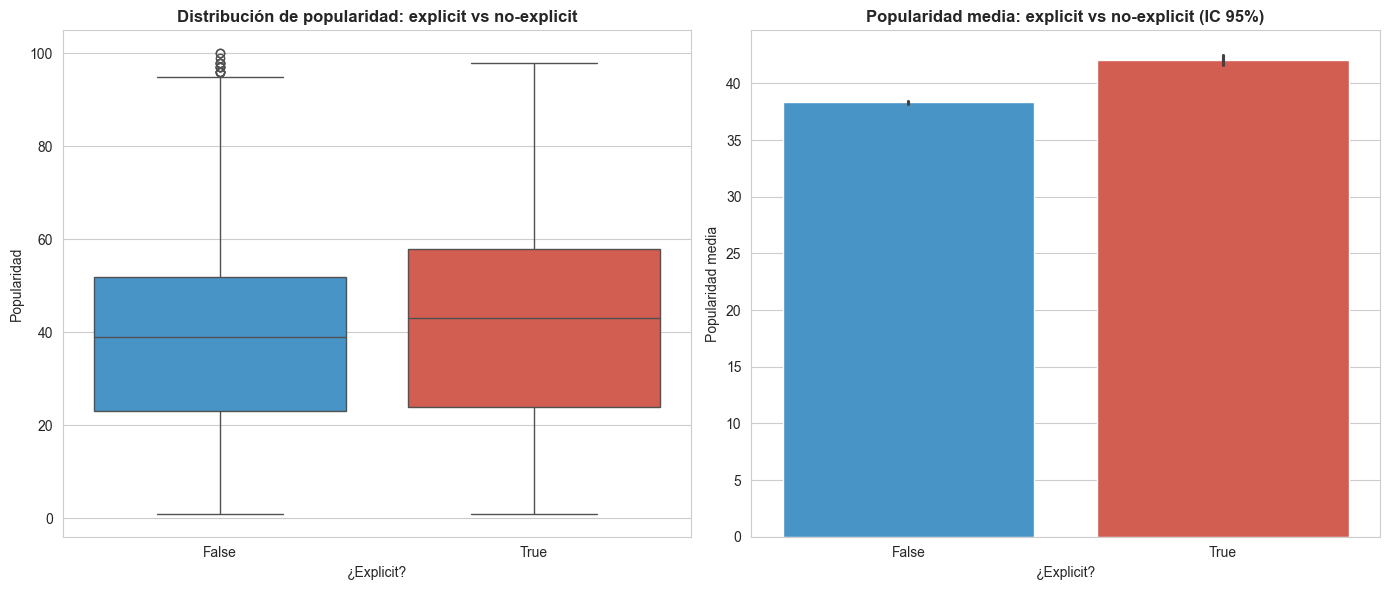

In [10]:
# 1. Proporción de canciones explicit vs no-explicit
print("Distribución explicit / no-explicit:")
print(df["explicit"].value_counts())
print(f"\nPorcentaje explicit: {df['explicit'].mean()*100:.2f}%")

# 2. Popularity media por categoría
print("\nPopularidad media por categoría explicit:")
stats_explicit = df.groupby("explicit")["popularity"].agg(["mean", "median", "std", "count"])
print(stats_explicit)

# 3. Diferencia
diff = df[df["explicit"]==True]["popularity"].mean() - df[df["explicit"]==False]["popularity"].mean()
print(f"\nDiferencia (explicit - no explicit): {diff:.2f} puntos")

# 4. Test estadístico: ¿es la diferencia significativa?
from scipy import stats
pop_explicit = df[df["explicit"]==True]["popularity"]
pop_no_explicit = df[df["explicit"]==False]["popularity"]
t_stat, p_value = stats.ttest_ind(pop_explicit, pop_no_explicit)
print(f"\nTest t de Student:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"  → Diferencia estadísticamente significativa (p < 0.05)")
else:
    print(f"  → Diferencia NO significativa estadísticamente")

# 5. Visualización: boxplot + barplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (muestra distribución completa)
sns.boxplot(data=df, x="explicit", y="popularity", hue="explicit", ax=axes[0], palette=["#3498db", "#e74c3c"], legend=False)
axes[0].set_title("Distribución de popularidad: explicit vs no-explicit", fontweight="bold")
axes[0].set_xlabel("¿Explicit?")
axes[0].set_ylabel("Popularidad")

# Barplot (muestra media con IC)
sns.barplot(data=df, x="explicit", y="popularity", hue="explicit", ax=axes[1], palette=["#3498db", "#e74c3c"], legend=False, errorbar="ci")
axes[1].set_title("Popularidad media: explicit vs no-explicit (IC 95%)", fontweight="bold")
axes[1].set_xlabel("¿Explicit?")
axes[1].set_ylabel("Popularidad media")

plt.tight_layout()
plt.savefig("explicit_comparacion.png", dpi=150, bbox_inches="tight")
plt.show()